In [1]:
%pip install feature-engine

Defaulting to user installation because normal site-packages is not writeableNote: you may need to restart the kernel to use updated packages.



In [69]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sb
import re
from feature_engine.outliers import Winsorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [3]:
df = pd.read_csv(r'Titanic-Dataset.csv')

In [4]:
df.head(20)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [6]:
df.shape

(891, 12)

In [7]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [10]:
df['Age'].count()

np.int64(714)

In [11]:
df['Age'].isna().sum()

np.int64(177)

In [12]:
df['Cabin'].unique()

array([nan, 'C85', 'C123', 'E46', 'G6', 'C103', 'D56', 'A6',
       'C23 C25 C27', 'B78', 'D33', 'B30', 'C52', 'B28', 'C83', 'F33',
       'F G73', 'E31', 'A5', 'D10 D12', 'D26', 'C110', 'B58 B60', 'E101',
       'F E69', 'D47', 'B86', 'F2', 'C2', 'E33', 'B19', 'A7', 'C49', 'F4',
       'A32', 'B4', 'B80', 'A31', 'D36', 'D15', 'C93', 'C78', 'D35',
       'C87', 'B77', 'E67', 'B94', 'C125', 'C99', 'C118', 'D7', 'A19',
       'B49', 'D', 'C22 C26', 'C106', 'C65', 'E36', 'C54',
       'B57 B59 B63 B66', 'C7', 'E34', 'C32', 'B18', 'C124', 'C91', 'E40',
       'T', 'C128', 'D37', 'B35', 'E50', 'C82', 'B96 B98', 'E10', 'E44',
       'A34', 'C104', 'C111', 'C92', 'E38', 'D21', 'E12', 'E63', 'A14',
       'B37', 'C30', 'D20', 'B79', 'E25', 'D46', 'B73', 'C95', 'B38',
       'B39', 'B22', 'C86', 'C70', 'A16', 'C101', 'C68', 'A10', 'E68',
       'B41', 'A20', 'D19', 'D50', 'D9', 'A23', 'B50', 'A26', 'D48',
       'E58', 'C126', 'B71', 'B51 B53 B55', 'D49', 'B5', 'B20', 'F G63',
       'C62 C64',

In [13]:
df['Embarked'].unique()

array(['S', 'C', 'Q', nan], dtype=object)

In [14]:
df['Embarked'].count()

np.int64(889)

**Total Rows: 891 passengers**

**Total Columns: 12 features**

**Target column: Survived**

**Missing values found in:**

  - **Age (177 missing)**

  - **Cabin (687 missing)**

  - **Embarked (2 missing)**

In [15]:
df['Age'].median()

28.0

In [16]:
df['Age'] = df['Age'].fillna(df['Age'].median())

In [17]:
df['Cabin'] = df['Cabin'].fillna('Unknown')

In [18]:
df['Embarked'].mode()[0]

'S'

In [19]:
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

In [20]:
df['Embarked'].isna().sum()

np.int64(0)

- **The "Age" column has a null value then we can this null values fill with the median value.**
- **This 'Cabin' column had a null value but we call fill this null values in the "Unknown" because we don't known which person stay which cabin.**
- **The 'Embarked' column alse have a null value but this column are categorical column that means we can fill this values to helping the mode(most Frequent value).**
- **During data cleaning, I handled missing values using statistical imputation techniques such as median and mode. I dropped highly incomplete features like Cabin to avoid bias. I performed feature engineering by creating FamilySize and encoded categorical variables to prepare the dataset for machine learning modeling**

In [21]:
df.to_csv('cleaned-Titanic-Dataset.csv', index=False)


**We can stored the cleaned dataset set**

In [22]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [23]:
columns_for_outlier = ['PassengerId', 'Survived', 'Pclass', 'Age', 'SibSp',
       'Parch', 'Fare']

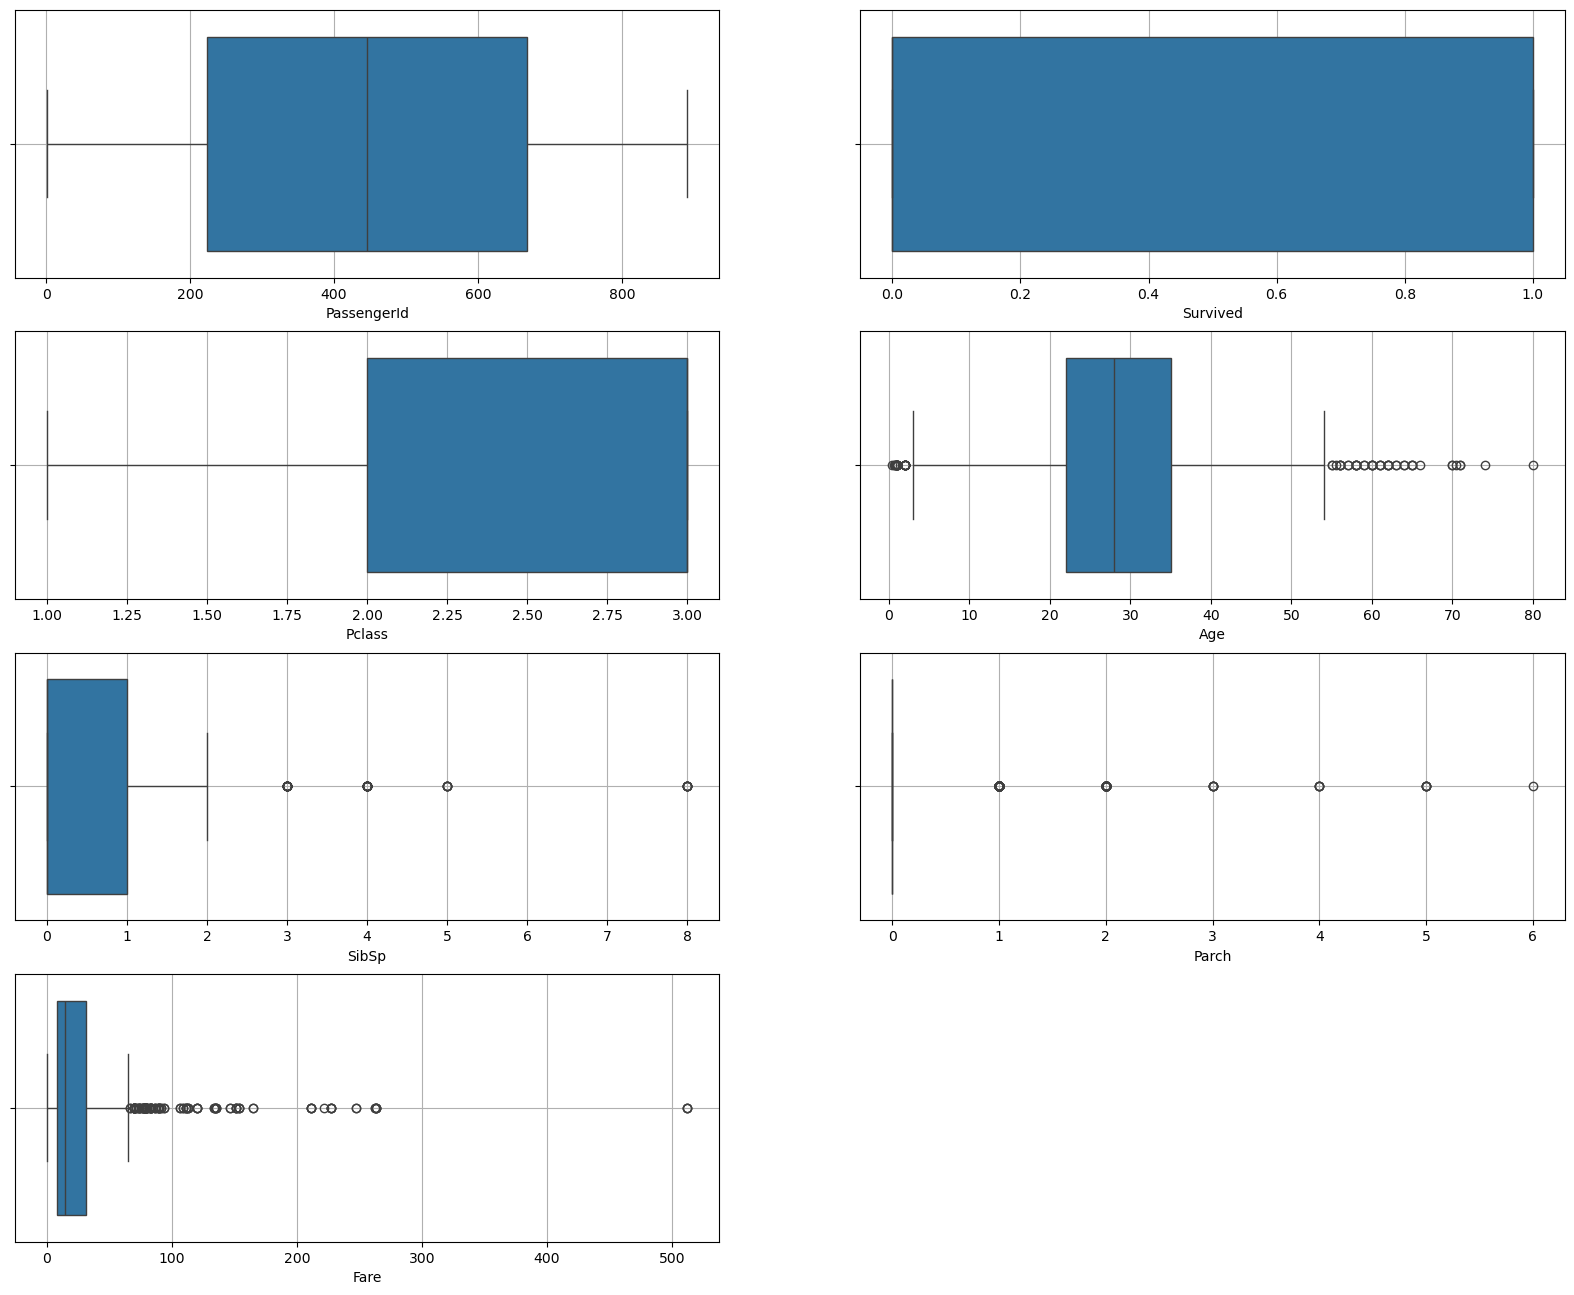

In [24]:
plt.figure(figsize=(20,16))

plt.subplot(4,2,1)
sb.boxplot(x=df['PassengerId'])
plt.grid()

plt.subplot(4,2,2)
sb.boxplot(x=df['Survived'])
plt.grid()

plt.subplot(4,2,3)
sb.boxplot(x=df['Pclass'])
plt.grid()

plt.subplot(4,2,4)
sb.boxplot(x=df['Age'])
plt.grid()

plt.subplot(4,2,5)
sb.boxplot(x=df['SibSp'])
plt.grid()

plt.subplot(4,2,6)
sb.boxplot(x=df['Parch'])
plt.grid()

plt.subplot(4,2,7)
sb.boxplot(x=df['Fare'])
plt.grid()

- **We are found the some column have a Extrime oulier 'SibSp', 'Parch' and'Fare'.**

In [25]:
df['Fare'].skew()

np.float64(4.787316519674893)

In [26]:
df['SibSp'].skew()

np.float64(3.6953517271630565)

In [27]:
df['Parch'].skew()

np.float64(2.7491170471010933)

**This oulier column skew is highly extrem but one column skew is not good to prediction.**

In [28]:
winsor_both = {
    "Both_tail":
        Winsorizer(capping_method='quantiles', tail='both',fold = 0.05, variables='Age'),

     "Right_tail":
        Winsorizer(capping_method='quantiles' , tail = 'right' ,fold = 0.05 , variables=['Fare','SibSp','Parch'])
}


In [29]:

for key, wz in winsor_both.items():
    winsor_both[key].fit(df)



In [30]:
for key, wz in winsor_both.items():
    df = winsor_both[key].transform(df)


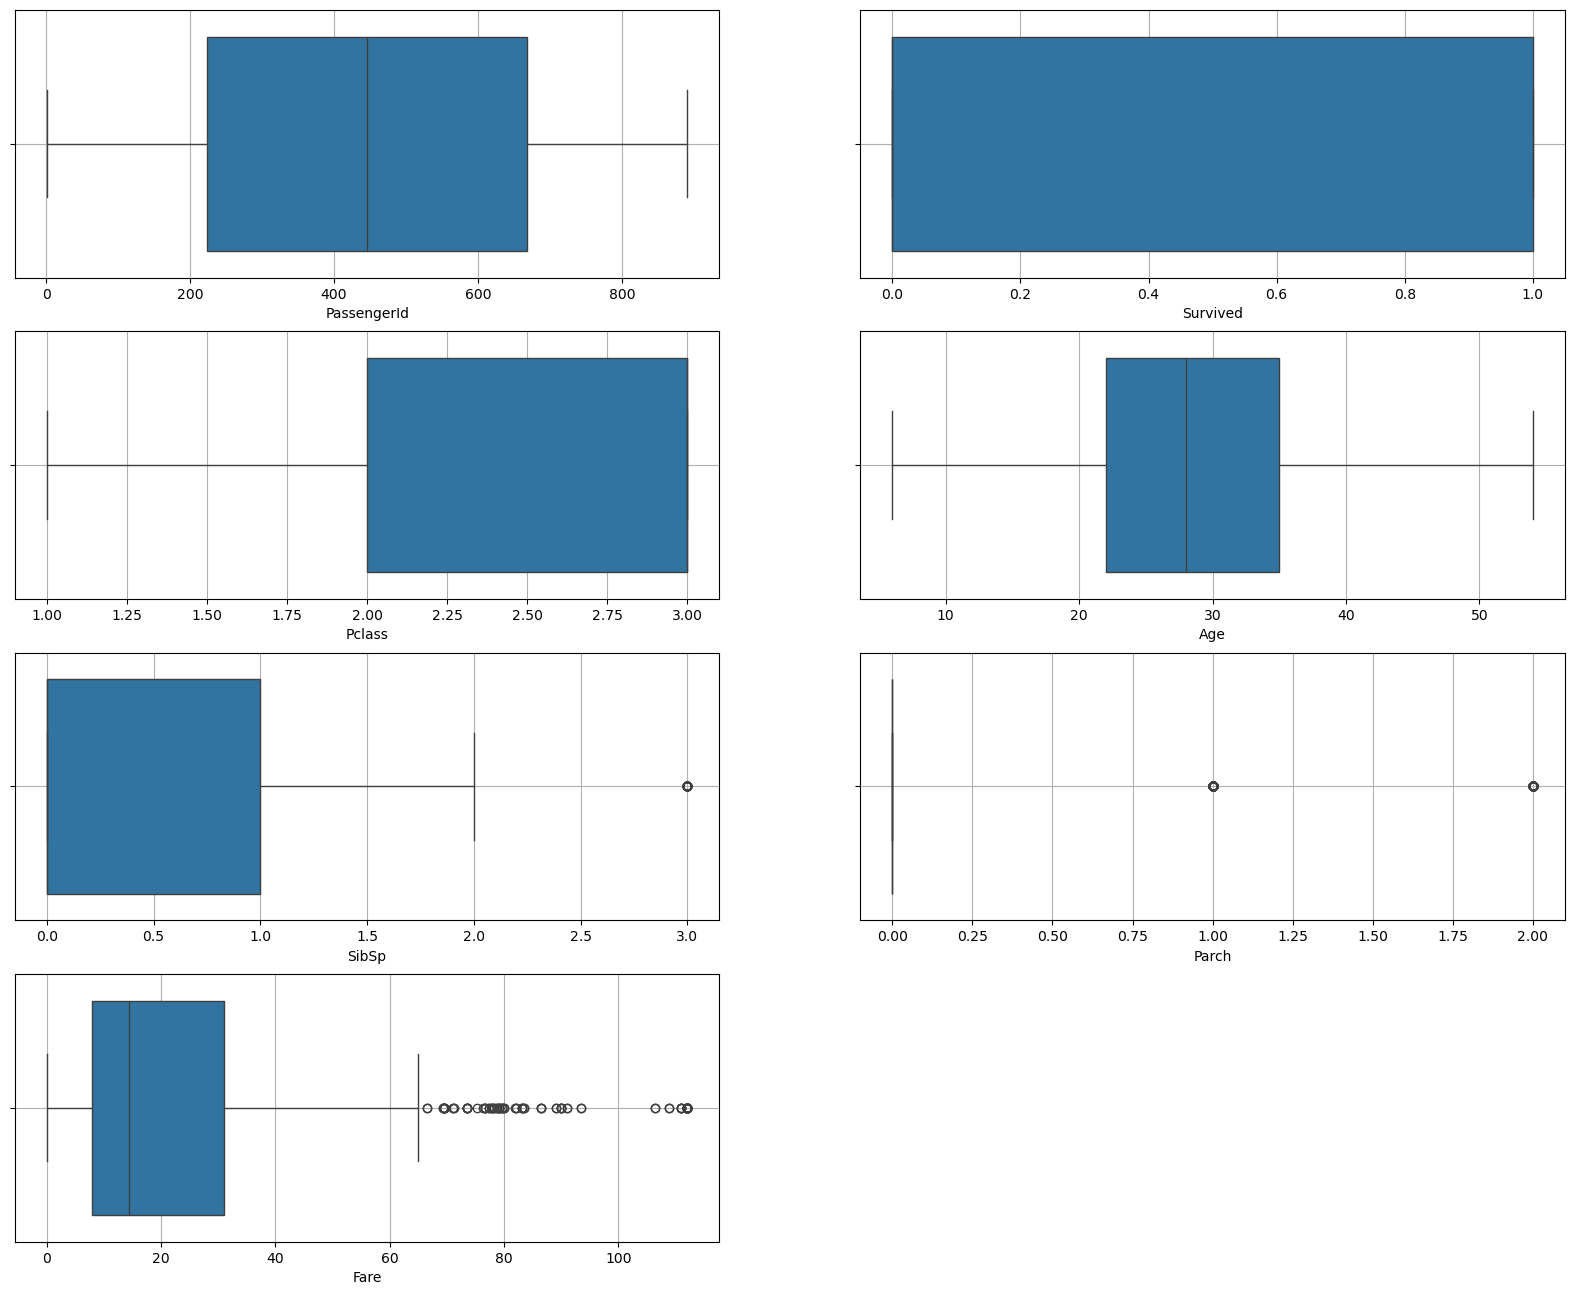

In [31]:
plt.figure(figsize=(20,16))

plt.subplot(4,2,1)
sb.boxplot(x=df['PassengerId'])
plt.grid()

plt.subplot(4,2,2)
sb.boxplot(x=df['Survived'])
plt.grid()

plt.subplot(4,2,3)
sb.boxplot(x=df['Pclass'])
plt.grid()

plt.subplot(4,2,4)
sb.boxplot(x=df['Age'])
plt.grid()

plt.subplot(4,2,5)
sb.boxplot(x=df['SibSp'])
plt.grid()

plt.subplot(4,2,6)
sb.boxplot(x=df['Parch'])
plt.grid()

plt.subplot(4,2,7)
sb.boxplot(x=df['Fare'])
plt.grid()

- **We applied the winsor to handling the outlier and this work good this reduce the outlier but not propoerly.**

In [47]:
# outliers[['Fare','Pclass','Survived']].sort_values(by='Fare', ascending=False)


In [33]:
col = ['SibSp', 'Parch','Fare']

In [34]:
for i in col:
    df[i + '_log'] = np.log1p(df[i])

In [35]:
df['Fare'].skew()

np.float64(1.717338608829254)

In [36]:
df['SibSp'].skew()

np.float64(1.9387121117591775)

- **Some Extrem oulier not handle porper way useing the winsor that we applied the "log transformation" for handling this oulier to analysis pupose.**
- **But after applying this outlier are showing the boxplot but this not effect to prediction.**
- **Skew is highly extrem.**

In [37]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked', 'SibSp_log',
       'Parch_log', 'Fare_log'],
      dtype='object')

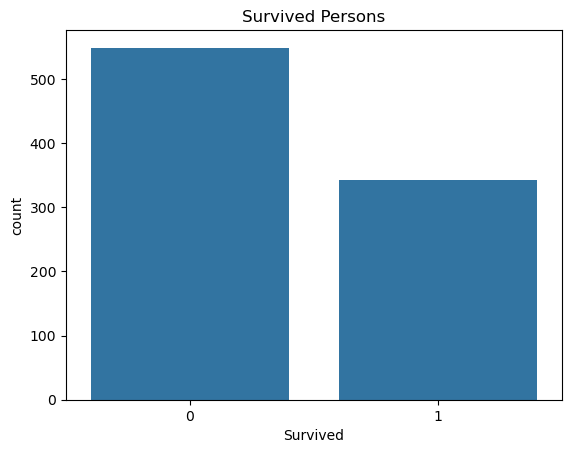

In [38]:
sb.countplot(x='Survived', data = df)
plt.title("Survived Persons")
plt.show()

- **The countplot shows that the number of non-survivors is significantly higher than survivors, indicating a low survival rate in the Titanic disaster**

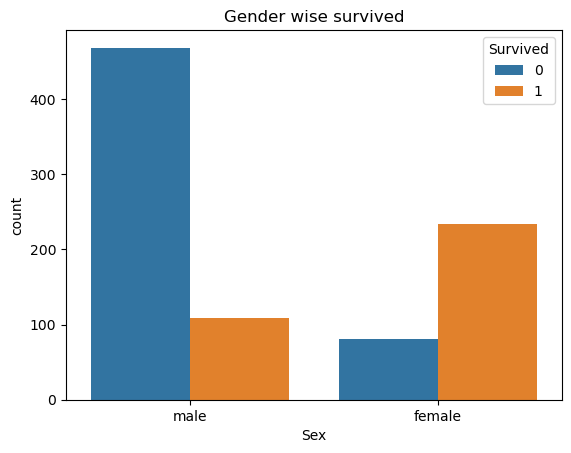

In [39]:
sb.countplot(x='Sex' , hue='Survived', data= df)
plt.title("Gender wise survived")
plt.show()

- **Survival strongly depended on gender. Women were given priority during evacuation, following the "women and children first" policy.**

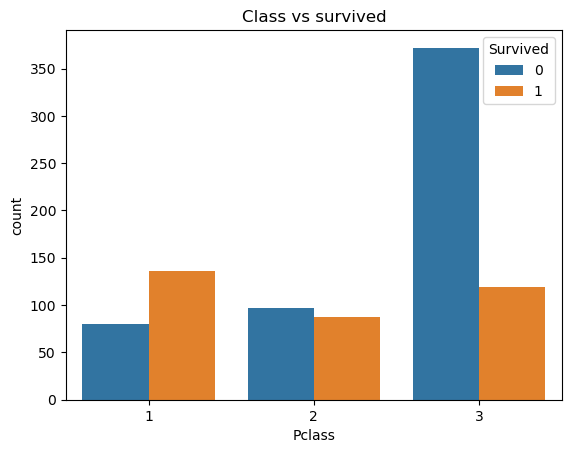

In [40]:
sb.countplot(x='Pclass', hue='Survived', data = df)
plt.title("Class vs survived")
plt.show()

- **Survival probability strongly depended on socio-economic status, as first-class passengers had better access to lifeboats compared to third-class passengers.**

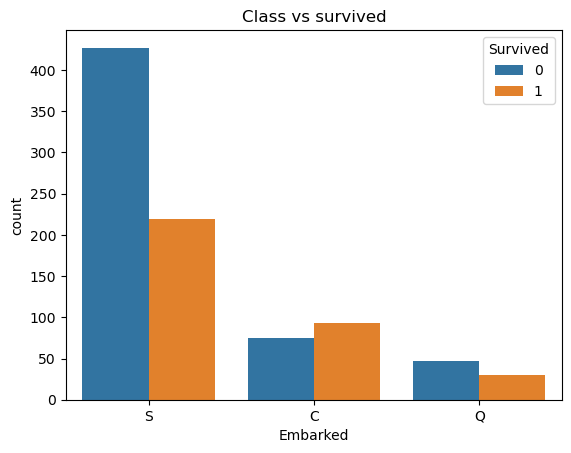

In [41]:
sb.countplot(x='Embarked', hue='Survived', data = df)
plt.title("Class vs survived")
plt.show()

- **Passengers who boarded from Cherbourg had higher survival probability, likely because more first-class passengers boarded there, while Southampton had more third-class passengers with lower survival.**

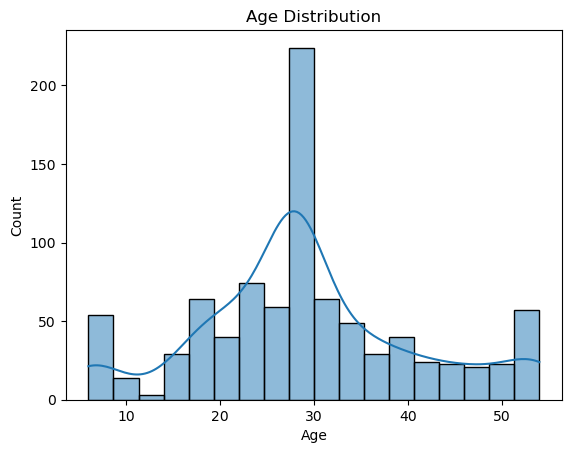

In [42]:
sb.histplot(df['Age'], kde= True)
plt.title("Age Distribution")
plt.show()

- **The passenger population was dominated by working-age adults, with fewer children and elderly individuals onboard.**

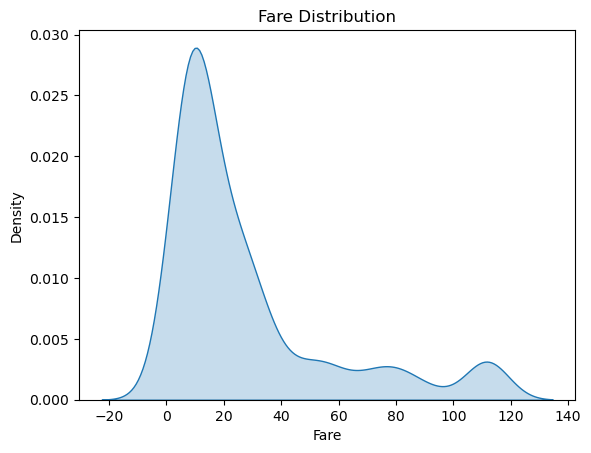

In [43]:
sb.kdeplot(df['Fare'], fill= True)
plt.title("Fare Distribution")
plt.show()

- **Fare distribution is highly right-skewed, indicating the presence of high-income passengers (first-class travelers) among a large population of low-fare passengers.**
- **Most passengers paid low ticket fares, while a few passengers paid extremely high fares**

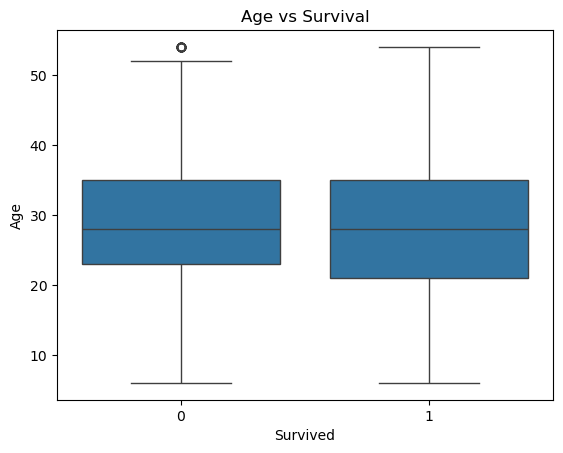

In [68]:
sb.boxplot(x='Survived', y='Age', data=df)
plt.title("Age vs Survival")
plt.show()


- **Children had slightly higher survival chances than adults.**
- **Age had a moderate influence on survival, but it was weaker compared to gender and passenger class.**

In [53]:
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1

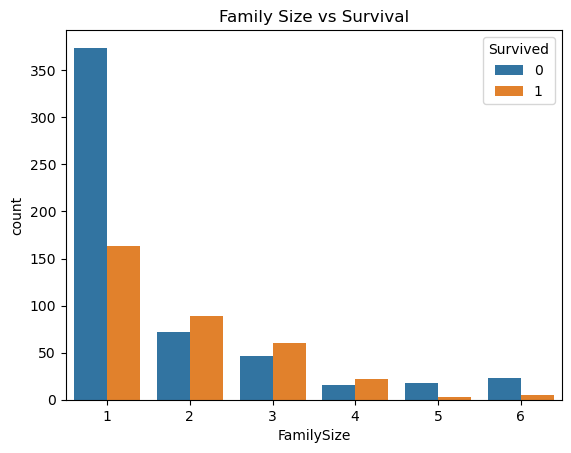

In [55]:
sb.countplot(x='FamilySize', hue='Survived', data=df)
plt.title("Family Size vs Survival")
plt.show()


- **Passengers traveling with small families had higher survival rates than those traveling alone or in large families.**
- **Survival probability depended on family size — moderate family groups had better chances of rescue, while individuals and large groups struggled more during evacuation.**

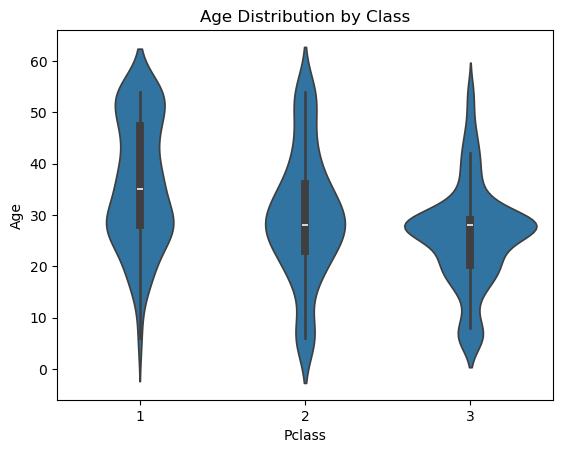

In [57]:
sb.violinplot(x='Pclass', y='Age', data=df)
plt.title("Age Distribution by Class")
plt.show()


- **Passenger age distribution varied across travel classes.**
- **First-class passengers were generally older, while third-class passengers included more young adults and children, reflecting socio-economic differences among classes.**

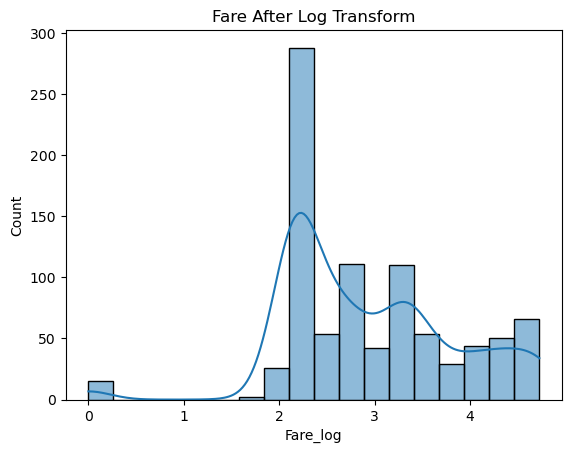

In [62]:
df['Fare_log'] = np.log1p(df['Fare'])

sb.histplot(df['Fare_log'], kde=True)
plt.title("Fare After Log Transform")
plt.show()


- **Log transformation reduced the skewness of the Fare feature.**
- **I applied log transformation to the Fare feature to reduce skewness and improve model performance without removing real observations.**

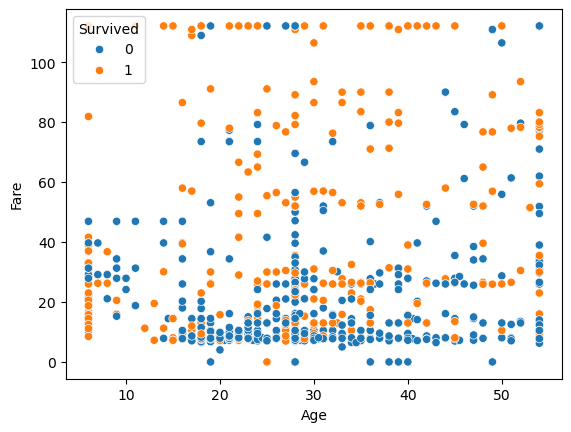

In [64]:
sb.scatterplot(x='Age', y='Fare', hue='Survived', data=df)
plt.show()


- **Passengers who paid higher fares had better survival chances.**
- **Survival was strongly associated with ticket fare rather than age, indicating socio-economic status played a key role in rescue probability.**

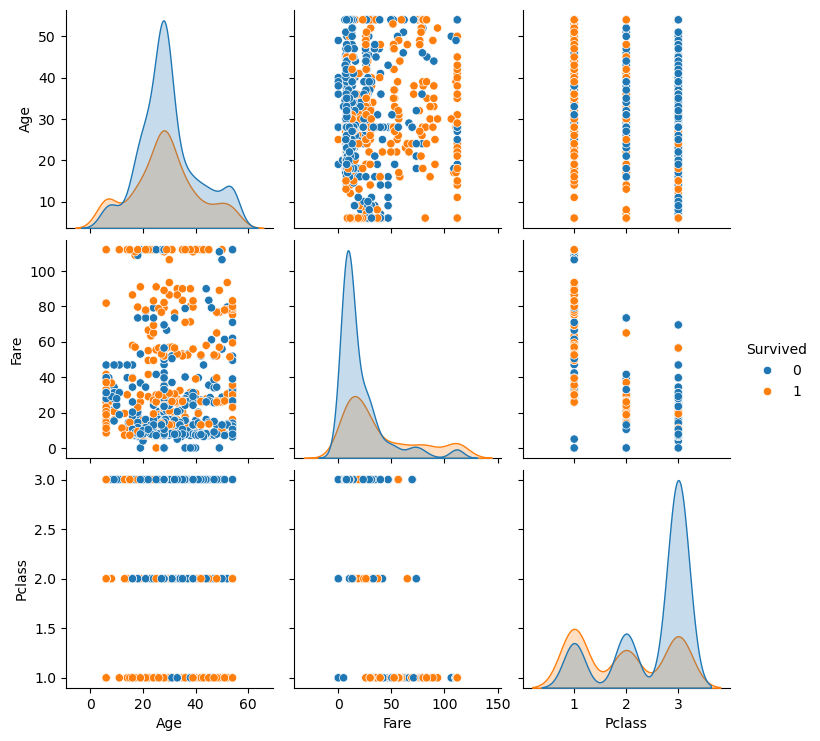

In [61]:
sb.pairplot(df[['Age','Fare','Pclass','Survived']], hue='Survived')
plt.show()


- **Survival depended mainly on passenger class and fare rather than age.**
- **Socio-economic features (class and fare) had stronger influence on survival compared to demographic features like age.**

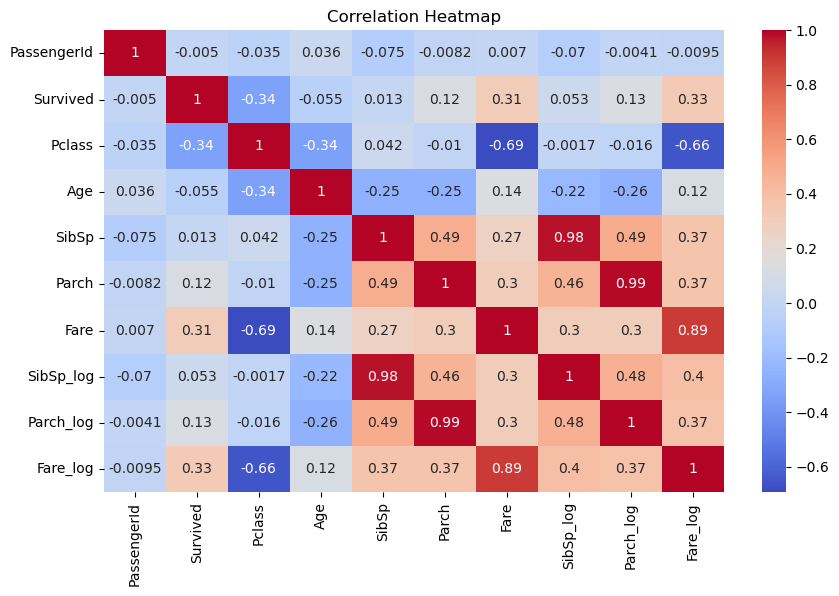

In [50]:
plt.figure(figsize=(10,6))
sb.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()


- **Passenger class and fare strongly influenced survival.**
- **Socio-economic features showed stronger correlation with survival compared to demographic features like age.**

In [70]:
df['Sex'] = df['Sex'].map({'male':0,'female':1})
df = pd.get_dummies(df, columns=['Embarked'], drop_first=True)


- **Converted categorical variables into numerical format for machine learning compatibility.**
- **The 'Sex' feature was label encoded, and the 'Embarked' feature was one-hot encoded to prevent ordinal relationships and multicollinearity.**

In [71]:
X = df[['Pclass','Sex','Age','Fare_log','FamilySize','Embarked_Q','Embarked_S']]
y = df['Survived']


- **Selected relevant features to predict passenger survival and defined the target variable.**
- **Socio-economic, demographic, and travel-related attributes were chosen as predictors for survival classification.**

In [72]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)


- **Dataset was split into training and testing sets to evaluate model performance.**
- **An 80-20 split was used to train the model on historical data and validate it on unseen data to prevent overfitting**

In [73]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)


LogisticRegression(max_iter=1000)

- **Logistic Regression model was trained using the training dataset.**
- **The model learned the relationship between passenger attributes and survival probability.**

In [74]:
y_pred = model.predict(X_test)


In [75]:
accuracy_score(y_test, y_pred)


0.7988826815642458

In [76]:
confusion_matrix(y_test, y_pred)


array([[88, 17],
       [19, 55]])

- **Model predictions were evaluated using accuracy score.**
- **Model predictions were evaluated using accuracy score.**

In [77]:
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.82      0.84      0.83       105
           1       0.76      0.74      0.75        74

    accuracy                           0.80       179
   macro avg       0.79      0.79      0.79       179
weighted avg       0.80      0.80      0.80       179



- **A logistic regression model was built to predict passenger survival on the Titanic dataset. After preprocessing and feature engineering, the model achieved approximately 80% accuracy. The model performed better at predicting non-survivors than survivors due to class imbalance, but overall showed reliable classification performance**